In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv('normalizados_passo2.csv', parse_dates=['datetime'])

treino = df[(df['datetime'] >= '2024-01-01') & (df['datetime'] <= '2024-03-30')].copy()
validacao = df[(df['datetime'] >= '2024-04-01') & (df['datetime'] <= '2024-06-30')].copy()

drop_cols = ['datetime', 'date', 'close', 'open', 'low', 'high',
             'volume', 'average', 'amount_stock', 'id_ticker', 'business', 'AD_Line']
treino.drop(columns=drop_cols, inplace=True, errors='ignore')
validacao.drop(columns=drop_cols, inplace=True, errors='ignore')

X_train = treino.drop(columns=['trend'])
y_train = treino['trend']

X_valid = validacao.drop(columns=['trend'])
y_valid = validacao['trend']

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_valid_scaled = pd.DataFrame(scaler.transform(X_valid), columns=X_valid.columns)


In [2]:
feature_methods = {
    'CFS_SubsetEval': ['EMA_3', 'EMA_5', 'EMA_7', 'EMA_9', 'EMA_11', 'SMA_3', 'SMA_5', 'SMA_9', 'SMA_7', 'SMA_11', 'Bollinger_Norm', 'std_open3', 'std_close3', 'std_open11', 'std_close7', 'std_open5', 'std_close11', 'std_open7', 'ADXR', 'std_close5', 'std_close9', 'std_open9']
,
    'ClassifierAttributeEval': ['EMA_3', 'SMA_3', 'ADXR', 'Bollinger_Norm', 'EMA_5', 'SMA_5', 'std_close3', 'std_open3', 'std_close5', 'std_open5', 'std_open7', 'SMA_7', 'std_close7', 'SMA_9', 'std_open9', 'std_close11', 'EMA_11', 'std_close9', 'std_open11', 'SMA_11', 'EMA_7', 'EMA_9']
,
    'CorrelationAttributeEval': ['EMA_3', 'EMA_5', 'EMA_7', 'EMA_9', 'EMA_11', 'SMA_3', 'SMA_5', 'SMA_9', 'SMA_7', 'SMA_11', 'Bollinger_Norm', 'std_open3', 'std_close3', 'std_open11', 'std_close7', 'std_open5', 'std_close11', 'std_open7', 'ADXR', 'std_close5', 'std_close9', 'std_open9']
,
    'PCA': ['Bollinger_Norm', 'SMA_11', 'EMA_11', 'SMA_9', 'EMA_9', 'SMA_7', 'EMA_7', 'EMA_5', 'SMA_5', 'EMA_3', 'SMA_3', 'std_open5', 'std_open7', 'std_open3', 'ADXR', 'std_close9', 'std_open11', 'std_close7', 'std_close5', 'std_close11', 'std_open9', 'std_close3']
,
    'Information_Gain': ['SMA_3', 'EMA_3', 'EMA_5', 'Bollinger_Norm', 'SMA_9', 'std_open3', 'ADXR', 'SMA_11', 'EMA_11', 'SMA_5', 'SMA_7', 'std_close9', 'EMA_7', 'std_close5', 'EMA_9', 'std_open9', 'std_close7', 'std_close3', 'std_open5', 'std_open7', 'std_open11', 'std_close11']
,
    'ReliefF': ['EMA_3', 'EMA_5', 'SMA_3', 'EMA_7', 'EMA_9', 'EMA_11', 'SMA_5', 'SMA_11', 'SMA_9', 'SMA_7', 'std_close3', 'std_open3', 'ADXR', 'Bollinger_Norm', 'std_close9', 'std_close11', 'std_open5', 'std_close5', 'std_close7', 'std_open9', 'std_open7', 'std_open11']
}


results = {}

for method, features in feature_methods.items():
    acc_list = []
    print(f"Avaliando: {method}")  
    
    for i in range(1, len(features)+1):
        selected_features = features[:i]
        X_tr = X_train_scaled[selected_features]
        X_val = X_valid_scaled[selected_features]
        
        model = RandomForestClassifier(n_estimators=100, random_state=42)   
        model.fit(X_tr, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_valid, preds)
        acc_list.append(acc)

    results[method] = acc_list


Avaliando: CFS_SubsetEval
Avaliando: ClassifierAttributeEval
Avaliando: CorrelationAttributeEval
Avaliando: PCA
Avaliando: Information_Gain
Avaliando: ReliefF


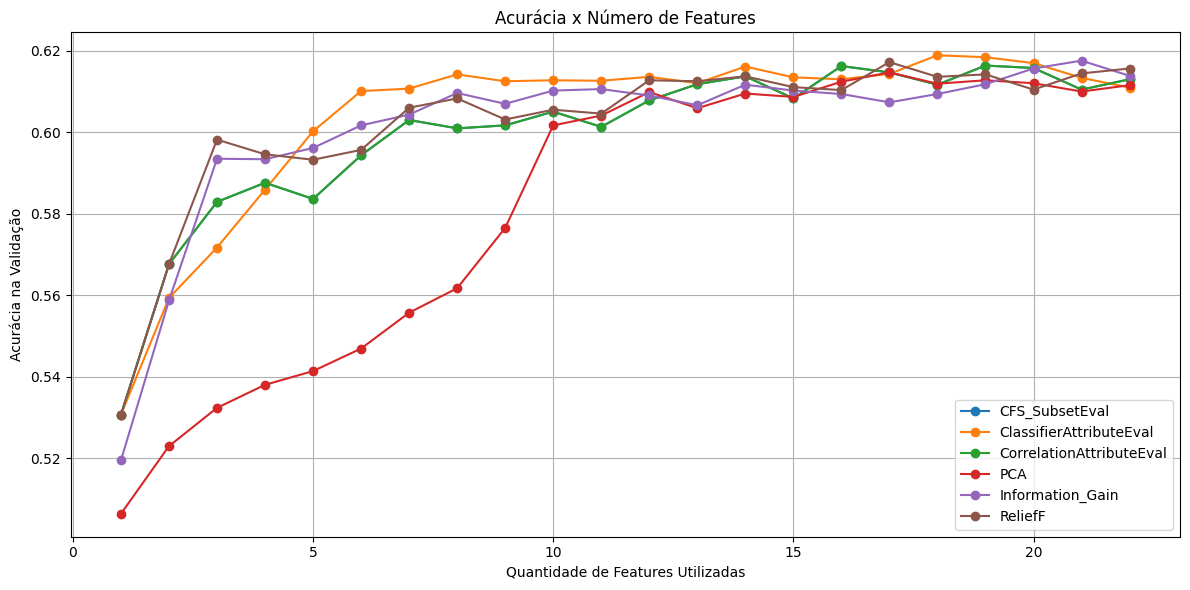

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for method, accs in results.items():
    plt.plot(range(1, len(accs)+1), accs, label=method, marker='o')

plt.xlabel('Number of Features Used')
plt.ylabel('Accuracy in Validation')
plt.title('Accuracy vs. Number of Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()